# 05 — Training and validation

- **Mapped issue:** [#12](https://github.com/majorgilles/transformer-2017-reproduction/issues/12)
- **Depends on:** `04_objective_optimizer_batching.ipynb` / issue #11.


In [1]:
#| default_exp training


## Goal

Turn the working notebook fixture into small exported training and validation functions with explicit inputs. The functions demonstrate parameter updates, evaluation without updates, and a deterministic learning curve without adding process or CLI infrastructure.


## One training pass

Each batch contains a source tensor shaped `(batch, source_length)` and a complete target tensor shaped `(batch, target_length + 1)`. The target is shifted into decoder inputs (`target[:, :-1]`) and next-token labels (`target[:, 1:]`). The model returns logits shaped `(batch, target_length, vocabulary_size)`; backpropagation and the optimizer then update its parameters.


In [2]:
#| export
from collections.abc import Sequence

import torch

from transformer_2017_reproduction.model import Transformer
from transformer_2017_reproduction.optimization import label_smoothed_loss

In [3]:
#| export
def train(
    model: Transformer,
    batches: Sequence[tuple[torch.Tensor, torch.Tensor]],
    optimizer: torch.optim.Optimizer,
) -> float:
    """Run one parameter-updating pass and return its mean batch loss."""
    if len(batches) == 0:
        raise ValueError("Cannot compute loss on empty sequence of batches.")

    total_loss = 0.0
    model.train()
    for source_token_ids, target_token_ids in batches:
        optimizer.zero_grad()

        decoder_input_ids = target_token_ids[:, :-1]
        logits = model(
            source_token_ids=source_token_ids,
            target_token_ids=decoder_input_ids,
        )

        next_token_labels = target_token_ids[:, 1:]
        loss = label_smoothed_loss(
            logits=logits,
            targets=next_token_labels,
            pad_token_id=model.pad_token_id,
        )
        loss.backward()

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(batches)

## Training changes model parameters

A training pass should produce a finite loss and update at least one model
parameter. This small deterministic fixture checks both behaviors.

In [4]:
torch.manual_seed(0)

fixture_model = Transformer(
    vocab_size=32,
    d_model=8,
    num_heads=2,
    d_ff=16,
    max_length=8,
    pad_token_id=0,
    dropout=0.0,
    num_layers=6,
)

# This fixed learning rate is only for the one-step fixture.
fixture_optimizer = torch.optim.Adam(
    fixture_model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.98),
    eps=1e-9,
)

# Each row is one source sentence.
# source_token_ids shape: (batch=1, source_length=4)
source_token_ids = torch.tensor(
    [
        [2, 5, 6, 3],
    ],
    dtype=torch.long,
)

# Complete target: BOS, two translation tokens, EOS.
# target_token_ids shape: (batch=1, complete_target_length=4)
target_token_ids = torch.tensor(
    [
        [2, 7, 8, 3],
    ],
    dtype=torch.long,
)

fixture_batches = [
    (source_token_ids, target_token_ids),
]

# clone() is necessary because model parameters are mutable.
parameters_before = [parameter.detach().clone() for parameter in fixture_model.parameters()]

training_loss = train(
    model=fixture_model,
    batches=fixture_batches,
    optimizer=fixture_optimizer,
)

parameters_changed = any(
    not torch.equal(before, after)
    for before, after in zip(
        parameters_before,
        fixture_model.parameters(),
        strict=True,
    )
)

assert torch.isfinite(torch.tensor(training_loss))
assert parameters_changed

print(f"Training loss: {training_loss:.4f}")
print(f"At least one parameter changed: {parameters_changed}")

Training loss: 5.8934
At least one parameter changed: True


## Validation measures without updating

Validation performs the same target shift, forward pass, and loss calculation as training, but it does not calculate gradients or call an optimizer. `model.eval()` selects evaluation behavior such as disabled dropout, while `@torch.no_grad()` prevents construction of a gradient graph.


In [5]:
#| export
@torch.no_grad()
def validate(
    model: Transformer,
    batches: Sequence[tuple[torch.Tensor, torch.Tensor]],
) -> float:
    """Return mean batch loss in evaluation mode without gradients."""
    if len(batches) == 0:
        raise ValueError("Cannot compute loss on empty sequence of batches.")

    total_loss = 0.0
    model.eval()
    for source_token_ids, target_token_ids in batches:
        decoder_input_ids = target_token_ids[:, :-1]
        logits = model(
            source_token_ids=source_token_ids,
            target_token_ids=decoder_input_ids,
        )

        next_token_labels = target_token_ids[:, 1:]
        loss = label_smoothed_loss(
            logits=logits,
            targets=next_token_labels,
            pad_token_id=model.pad_token_id,
        )
        total_loss += loss.item()

    return total_loss / len(batches)

### Validation preserves model parameters

Validation should return a finite loss while leaving every model parameter unchanged.

In [6]:
parameters_before_validation = [
    parameter.detach().clone() for parameter in fixture_model.parameters()
]

validation_loss = validate(
    model=fixture_model,
    batches=fixture_batches,
)

parameters_unchanged = all(
    torch.equal(before, after)
    for before, after in zip(
        parameters_before_validation,
        fixture_model.parameters(),
        strict=True,
    )
)

assert torch.isfinite(torch.tensor(validation_loss))
assert parameters_unchanged
assert not fixture_model.training

print(f"Validation loss: {validation_loss:.4f}")
print(f"All parameters unchanged: {parameters_unchanged}")

Validation loss: 5.1963
All parameters unchanged: True


## Repeated passes produce a learning curve

This deterministic fixture uses the same tiny data for training and validation
so the curve demonstrates loop behavior, not generalization to unseen data.

In [7]:
torch.manual_seed(1)

training_losses: list[float] = []
validation_losses: list[float] = []

model = Transformer(
    vocab_size=32,
    d_model=8,
    num_heads=2,
    d_ff=16,
    max_length=8,
    pad_token_id=0,
    dropout=0.0,
    num_layers=6,
)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.98),
    eps=1e-9,
)
NUM_EPOCHS = 20

for e in range(1, NUM_EPOCHS + 1):
    training_loss = train(model, fixture_batches, optimizer)
    training_losses.append(training_loss)
    validation_loss = validate(model, fixture_batches)
    validation_losses.append(validation_loss)

    if e % 5 == 0:
        print(
            f"Pass {e:>2}: "
            f"training loss = {training_loss:.4f}, "
            f"validation loss = {validation_loss:.4f}"
        )

assert training_losses[-1] < training_losses[0]
assert validation_losses[-1] < validation_losses[0]

Pass  5: training loss = 3.3813, validation loss = 3.2248


Pass 10: training loss = 2.9432, validation loss = 2.9183


Pass 15: training loss = 2.8536, validation loss = 2.8295


Pass 20: training loss = 2.6935, validation loss = 2.6553


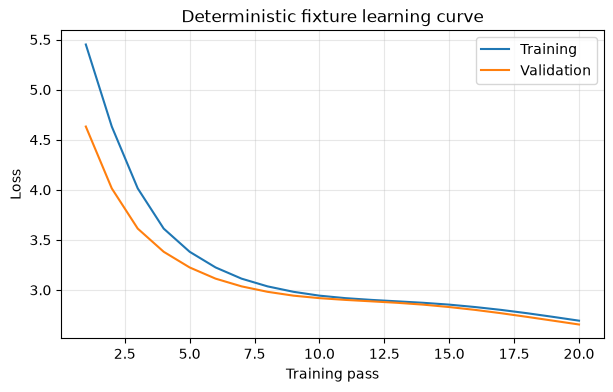

In [8]:
import matplotlib.pyplot as plt

pass_numbers = range(1, NUM_EPOCHS + 1)

figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(pass_numbers, training_losses, label="Training")
axis.plot(pass_numbers, validation_losses, label="Validation")
axis.set_xlabel("Training pass")
axis.set_ylabel("Loss")
axis.set_title("Deterministic fixture learning curve")
axis.legend()
axis.grid(alpha=0.3)
plt.show()

## Explicitly deferred

Standalone CLI and process orchestration are unnecessary for this learning notebook. Checkpoint persistence and restart belong to notebook 06. Mixed precision, WMT-scale data, Noam schedule wiring, gradient accumulation, and campaign configuration belong to later calibration and training notebooks.


## Completion evidence

The notebook demonstrates that training updates parameters, validation preserves them, and repeated passes reduce fixture loss. The same fixture is intentionally used for training and validation; these curves demonstrate execution and mode boundaries, not generalization to unseen data.
